# Aggressive Single-Frequency Init: Phase Alignment Convergence

Each neuron $m$ is initialised with energy at a **uniformly assigned** Fourier frequency $\rho^*_m$
(round-robin over all non-trivial frequencies) and a prescribed initial $\mathrm{Re}(\varphi_m[\rho^*_m])$,
swept from large to small. A single training run reveals how convergence speed depends on initial phase alignment.


In [464]:
import sys
sys.path.insert(0, '..')

import torch
import numpy as np
import matplotlib.pyplot as plt

from src import Config, SphericalTrainer, get_task, get_basis
from src.plotting import setup_plot_style

setup_plot_style()


## 3. Aggressive Single-Frequency Init: Phase Convergence Comparison

Each neuron $m$ is initialised with energy concentrated at a **randomly drawn** Fourier
frequency $\rho^*_m$, and with a prescribed initial phase alignment
$\mathrm{Re}(\varphi_m[\rho^*_m])$, swept from **large** (near $+1$) to **small** (near $-1$).

Recall:
$$\varphi_m[\rho] = \frac{\overline{\hat{\xi}_m[\rho]}\,\hat{\theta}_m[\rho]^2}{|\overline{\hat{\xi}_m[\rho]}\,\hat{\theta}_m[\rho]^2|}$$

With $\hat{\theta}_m[\rho^*_m]=\alpha\,e^{i\cdot 0}$ and $\hat{\xi}_m[\rho^*_m]=\alpha\,e^{i\psi_m}$:
$$\mathrm{Re}(\varphi_m[\rho^*_m])=\cos(\psi_m),\quad\psi_m=\arccos(\mathrm{Re}(\varphi_m[\rho^*_m]))$$

This single run lets us compare convergence speed across all initial alignment levels simultaneously.

In [465]:
def init_single_freq_rand_phase(trainer, freq_per_neuron, rng=None):
    """Init each neuron at its assigned frequency with random phases for both θ and ξ,
    designed so Re(φ_m[ρ*_m]) is uniformly distributed on [-1, 1] and
    Im(φ_m[ρ*_m]) = sin(Δ) is symmetric around 0.

    Strategy:
      1. Δ   = linspace(-π, π, width)   (equally spaced angles, shuffled)
      2. ψ_θ ~ Uniform[0, 2π)           (random first layer phase)
      3. ψ_ξ = 2ψ_θ − Δ                (derive second layer phase)
    Re(φ) = cos(Δ) and Im(φ) = sin(Δ) are both evenly spread on the unit circle.
    """
    if rng is None:
        rng = np.random.default_rng()

    basis   = trainer.basis
    d_vocab = trainer.model.d_vocab
    width   = trainer.model.width
    device  = trainer.device

    W_in_dft  = torch.zeros(width, d_vocab, dtype=torch.cfloat)
    W_out_dft = torch.zeros(width, d_vocab, dtype=torch.cfloat)

    # Equally spaced angles on the unit circle → φ values evenly distributed on [-π, π]
    # This makes both Re(φ)=cos(Δ) and Im(φ)=sin(Δ) visually uniform
    delta_grid  = np.linspace(-np.pi+0.05, np.pi-0.05, width, endpoint=False)
    idx_shuffle = rng.permutation(width)               # shuffle so angle order ≠ freq order
    delta_grid  = delta_grid[idx_shuffle]

    for m in range(width):
        k_idx     = int(freq_per_neuron[m])
        psi_theta = rng.uniform(0, 2 * np.pi)          # ① random first layer
        delta     = delta_grid[m]                      # ② equally spaced angle Δ ∈ [-π, π)
        psi_xi    = 2 * psi_theta - delta              # ③ derive second layer

        k_tuple     = basis.get_frequency_tuple(k_idx)
        neg_k_tuple = tuple((-kj) % nj for kj, nj in zip(k_tuple, basis.n))
        neg_k_idx   = basis.tuple_to_index(neg_k_tuple)

        if neg_k_idx == k_idx:  # self-conjugate
            W_in_dft[m, k_idx]  = np.exp(1j * psi_theta)
            W_out_dft[m, k_idx] = np.exp(1j * psi_xi)
        else:                   # conjugate pair
            amp = 1.0 / np.sqrt(2)
            W_in_dft[m, k_idx]      = amp * np.exp( 1j * psi_theta)
            W_in_dft[m, neg_k_idx]  = amp * np.exp(-1j * psi_theta)
            W_out_dft[m, k_idx]     = amp * np.exp( 1j * psi_xi)
            W_out_dft[m, neg_k_idx] = amp * np.exp(-1j * psi_xi)

    w_in  = basis.inverse_transform(W_in_dft).real
    w_out = basis.inverse_transform(W_out_dft).real
    w_in  = w_in  / w_in.norm(dim=1, keepdim=True)
    w_out = w_out / w_out.norm(dim=1, keepdim=True)

    with torch.no_grad():
        trainer.model.W_in.data  = w_in.float().to(device)
        trainer.model.W_out.data = w_out.T.float().to(device)

    freq_counts = np.bincount(freq_per_neuron, minlength=d_vocab)
    print('Freq assignments: ' + ', '.join(
        f'k={basis.get_frequency_tuple(k)}:{freq_counts[k]}'
        for k in range(1, d_vocab) if freq_counts[k]))


In [466]:
config_sf = Config(
    task_name='modular_addition',
    n=[3, 5],
    width=16,
    act_type='Quad',
    init_scale=0.5,
    share_embed=True,
    init_type='iid',
    stage1_enabled=True,
    stage1_lr=1e-2,
    stage1_num_epochs=7000,
    stage1_optimizer='SGD',
    stage1_freeze_scales=True,
    stage2_enabled=False,
    print_every=1000,
    track_phases=True,
    track_scales=True,
    snapshot_every=100,
    seed=42,
)

trainer_sf = SphericalTrainer(config_sf)
width_sf   = trainer_sf.model.width
d_vocab_sf = trainer_sf.model.d_vocab

# Uniformly assign frequencies: cycle through all non-trivial freqs 1..d_vocab-1
freq_per_neuron = (np.arange(width_sf) % (d_vocab_sf - 1)) + 1

# Random phases for both layers (independent uniform)
rng = np.random.default_rng(seed=0)
init_single_freq_rand_phase(trainer_sf, freq_per_neuron, rng)

# Save initial weights before training
W_in_init  = trainer_sf.model.W_in.detach().cpu().clone()
W_out_init = trainer_sf.model.W_out.detach().cpu().clone()

# Compute actual initial Re(φ_m[ρ*_m]) from saved weights (used for coloring)
phi_init_values = np.zeros(width_sf)
_basis = trainer_sf.basis
for m, k_idx in enumerate(freq_per_neuron):
    w_in  = W_in_init[m].numpy();    w_in  = w_in  / np.linalg.norm(w_in)
    w_out = W_out_init[:, m].numpy(); w_out = w_out / np.linalg.norm(w_out)
    th   = _basis.transform_paper(torch.from_numpy(w_in).float().unsqueeze(0))[0]
    xi   = _basis.transform_paper(torch.from_numpy(w_out).float().unsqueeze(0))[0]
    prod = torch.conj(xi[k_idx]) * (th[k_idx] ** 2)
    phi_init_values[m] = (prod / (torch.abs(prod) + 1e-20)).real.item()

print(f'Initial Re(φ) range: [{phi_init_values.min():.3f}, {phi_init_values.max():.3f}]')

stage1_history_sf, _ = trainer_sf.train()


Initialized SphericalTrainer:
  Task: ModularAddition(n=[3, 5], vocab_size=15)
  Basis: FourierBasis(n=[3, 5], size=15)
  Device: cpu
  Data size: 225
  Model:
WideNetworkScaleSphere(
  d_vocab=15,
  width=16,
  act_type='Quad',
  share_embed=True,
  d_input=15,
  scale_in=0.5000,
  scale_out=0.5000
)
Freq assignments: k=(0, 1):2, k=(0, 2):2, k=(0, 3):1, k=(0, 4):1, k=(1, 0):1, k=(1, 1):1, k=(1, 2):1, k=(1, 3):1, k=(1, 4):1, k=(2, 0):1, k=(2, 1):1, k=(2, 2):1, k=(2, 3):1, k=(2, 4):1
Initial Re(φ) range: [-0.999, 1.000]

Stage 1: Projected GD (Directions only, Scale fixed)
Fixed scale_in = 0.5000, scale_out = 0.5000
Learning rates: W_in=0.005000, W_out=0.010000
Epoch     0 | Loss: 609.300720 | Acc: 0.0578
Epoch  1000 | Loss: 608.908936 | Acc: 0.3422
Epoch  2000 | Loss: 608.731506 | Acc: 0.5067
Epoch  3000 | Loss: 608.665161 | Acc: 0.6044
Epoch  4000 | Loss: 608.631653 | Acc: 0.6444
Epoch  5000 | Loss: 608.627380 | Acc: 0.6711
Epoch  6000 | Loss: 608.626953 | Acc: 0.6711

Stage 1 Final |

In [467]:
# Compute Fourier transform of weights (init and trained)
basis = trainer_sf.basis

W_in  = trainer_sf.model.W_in.detach().cpu()
W_out = trainer_sf.model.W_out.detach().cpu()

# Normalize to unit vectors
W_in_norm       = W_in       / W_in.norm(dim=1, keepdim=True)
W_out_norm      = W_out      / W_out.norm(dim=0, keepdim=True)
W_in_init_norm  = W_in_init  / W_in_init.norm(dim=1, keepdim=True)
W_out_init_norm = W_out_init / W_out_init.norm(dim=0, keepdim=True)

W_in_dft       = basis.transform(W_in_norm)
W_out_dft      = basis.transform(W_out_norm.T)
W_in_init_dft  = basis.transform(W_in_init_norm)
W_out_init_dft = basis.transform(W_out_init_norm.T)

W_in_mag       = torch.abs(W_in_dft).numpy()
W_out_mag      = torch.abs(W_out_dft).numpy()
W_in_init_mag  = torch.abs(W_in_init_dft).numpy()
W_out_init_mag = torch.abs(W_out_init_dft).numpy()

print(f'W_in_dft shape:  {W_in_dft.shape}')
print(f'W_out_dft shape: {W_out_dft.shape}')


W_in_dft shape:  torch.Size([16, 15])
W_out_dft shape: torch.Size([16, 15])


In [468]:
from src.utils import normalize_to_pi

# Compute and print phases for all neurons
M = config_sf.width

print(f"Double Phase Verification: 2φ_in ≈ ψ_out")
print(f"=" * 80)
print(f"{'Neuron':<8} {'k':<12} {'φ_in':<12} {'ψ_out':<12} {'2φ_in':<12} {'|diff|':<10} {'Match?':<8}")
print(f"-" * 80)

match_count = 0
threshold = 0.3

for m in range(M):
    dom_freq = basis.get_dominant_frequency(W_in_dft[m])
    k_tuple  = basis.get_frequency_tuple(dom_freq)

    phi_in     = basis.get_phase(W_in_dft[m], dom_freq)
    psi_out    = basis.get_phase(W_out_dft[m], dom_freq)
    two_phi_in = normalize_to_pi(2 * phi_in)

    diff  = abs(normalize_to_pi(two_phi_in - psi_out))
    match = diff < threshold
    if match:
        match_count += 1

    print(f"{m:<8} {str(k_tuple):<12} {phi_in:<12.4f} {psi_out:<12.4f} {two_phi_in:<12.4f} {diff:<10.4f} {'YES' if match else 'NO':<8}")

print(f"-" * 80)
print(f"Phase alignment (|2φ_in - ψ_out| < {threshold}): {match_count}/{M} ({100*match_count/M:.1f}%)")


Double Phase Verification: 2φ_in ≈ ψ_out
Neuron   k            φ_in         ψ_out        2φ_in        |diff|     Match?  
--------------------------------------------------------------------------------
0        (0, 1)       0.9839       1.9683       1.9678       0.0006     YES     
1        (0, 2)       -2.0851      2.1130       2.1130       0.0000     YES     
2        (0, 2)       -1.7470      2.7891       2.7892       0.0001     YES     
3        (0, 1)       1.1180       2.2363       2.2361       0.0002     YES     
4        (1, 0)       -1.8541      2.5849       2.5750       0.0098     YES     
5        (1, 1)       2.3978       -1.4875      -1.4875      0.0001     YES     
6        (1, 2)       2.7847       -0.7137      -0.7139      0.0001     YES     
7        (1, 3)       0.5644       1.1291       1.1288       0.0003     YES     
8        (1, 4)       0.0083       0.0162       0.0165       0.0004     YES     
9        (1, 0)       2.5849       -1.1130      -1.1134      0.0004 

In [469]:
def extract_phi_per_neuron(snapshots, basis, freq_per_neuron):
    """Compute Re and Im of φ_m[ρ*_m] at each snapshot, using each neuron's own freq."""
    epochs    = []
    real_traj = []
    imag_traj = []

    for epoch, W_in, W_out in snapshots:
        epochs.append(epoch)
        real_row, imag_row = [], []
        for m, k_idx in enumerate(freq_per_neuron):
            w_in  = W_in[m];     w_in  = w_in  / np.linalg.norm(w_in)
            w_out = W_out[:, m]; w_out = w_out / np.linalg.norm(w_out)

            theta_hat = basis.transform_paper(
                torch.from_numpy(w_in).float().unsqueeze(0))[0]
            xi_hat    = basis.transform_paper(
                torch.from_numpy(w_out).float().unsqueeze(0))[0]

            prod = torch.conj(xi_hat[k_idx]) * (theta_hat[k_idx] ** 2)
            phi  = prod / (torch.abs(prod) + 1e-20)
            real_row.append(phi.real.item())
            imag_row.append(phi.imag.item())

        real_traj.append(real_row)
        imag_traj.append(imag_row)

    return np.array(epochs), np.array(real_traj), np.array(imag_traj)  # (T,), (T,M), (T,M)


epochs_sf, phi_real_traj, phi_imag_traj = extract_phi_per_neuron(
    stage1_history_sf.param_snapshots, trainer_sf.basis, freq_per_neuron
)
print(f'Snapshots: {len(epochs_sf)},  Neurons: {phi_real_traj.shape[1]}')


Snapshots: 70,  Neurons: 16


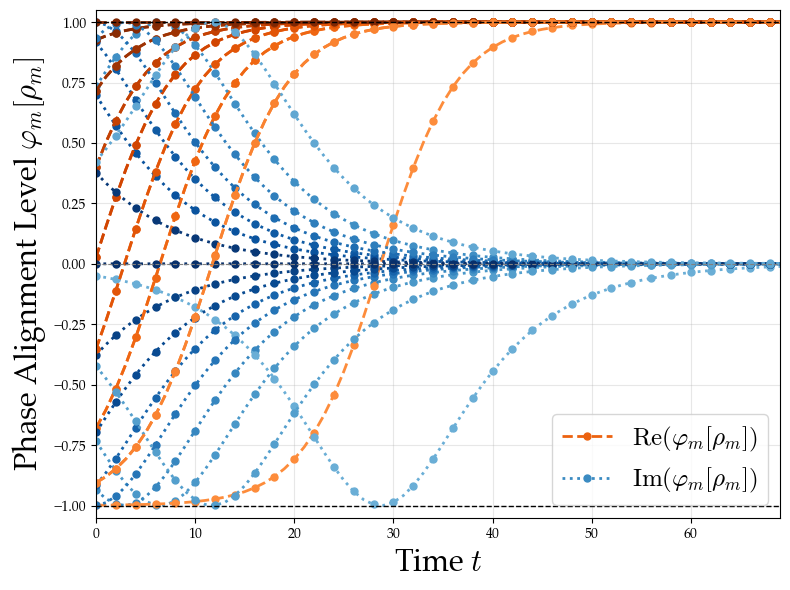

In [470]:
# DAR plot: Re (blue family, solid) vs Im (orange family, dotted)
# Shade within each family = rank by initial Re(φ): light → dark

from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(8, 6))

# Convert epochs to time: t = lr * epoch
times_sf = epochs_sf * config_sf.stage1_lr

# Rank neurons by initial Re(φ) to assign shade (light=low, dark=high)
ranks = np.argsort(np.argsort(phi_init_values))  # 0..width_sf-1
shade = 0.5 + 0.50 * ranks / (width_sf - 1)    # map to [0.45, 0.95]

blues   = plt.cm.Blues
oranges = plt.cm.Oranges

# Marker every 200 epochs: snapshots are every snapshot_every epochs,
# so markevery = 200 // snapshot_every
snapshot_every = config_sf.snapshot_every
markevery = max(1, 200 // snapshot_every)

for m in range(width_sf):
    s = shade[m]
    ax.plot(times_sf, phi_real_traj[:, m],
            color=oranges(s), linewidth=2, linestyle='--',
            marker='o', markersize=5, markevery=markevery)
    ax.plot(times_sf, phi_imag_traj[:, m],
            color=blues(s),   linewidth=2, linestyle=':',
            marker='o', markersize=5, markevery=markevery)

ax.axhline( 1.0, color='black', linestyle='--', linewidth=1.0)
ax.axhline( 0.0, color='gray',  linestyle='--', linewidth=0.8)
ax.axhline(-1.0, color='black', linestyle='--', linewidth=1.0)

legend_handles = [
    Line2D([0], [0], color=oranges(0.65), linewidth=2.0, linestyle='--',
           marker='o', markersize=5, label=r'$\mathrm{Re}(\varphi_m[\rho_m])$'),
    Line2D([0], [0], color=blues(0.65),   linewidth=2.0, linestyle=':',
           marker='o', markersize=5, label=r'$\mathrm{Im}(\varphi_m[\rho_m])$'),
]
ax.legend(handles=legend_handles, fontsize=18, loc='lower right')

ax.set_xlabel(r'Time $t$', fontsize=22)
ax.set_ylabel(r'Phase Alignment Level $\varphi_m[\rho_m]$', fontsize=22)

ax.set_xlim(times_sf[0], times_sf[-1])
ax.set_ylim(-1.05, 1.05)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/abelian_phase_alignment.jpg', format='jpg', dpi=300, bbox_inches='tight')
plt.show()


## 4. Phase-Aligned Init: Scale Evolution per Frequency

All neurons are initialised **IID on the unit sphere** (energy spread over all frequencies),
but with ξ phases set so that $\varphi_m[\rho]=1$ for **every** irrep $\rho$ and neuron $m$:
$$\hat{\xi}_m[\rho] = |\hat{\theta}_m[\rho]|\,e^{\,i\cdot 2\arg(\hat{\theta}_m[\rho])}$$

Since phase alignment is already perfect at $t=0$, the interesting dynamics are in the
**scales** $\alpha_m[\rho] = |\hat{\theta}_m[\rho]|$: which frequencies grow or decay?

In [471]:
def init_phase_aligned(trainer, rng=None):
    """IID init with φ_m[ρ]=1 for every irrep ρ and neuron m.

    For each neuron m:
      1. θ_m ~ IID on unit sphere  (random magnitudes α_m[ρ] and phases ψ_m[ρ])
      2. ξ̂_m[ρ] = α_m[ρ] · e^(i·2ψ_m[ρ])   (same magnitude, doubled phase)
    Then φ_m[ρ] = conj(ξ̂_m[ρ])·θ̂_m[ρ]²/|...| = e^(−2iψ)·e^(2iψ) = 1  ∀ρ
    """
    if rng is None:
        rng = np.random.default_rng()

    basis   = trainer.basis
    d_vocab = trainer.model.d_vocab
    width   = trainer.model.width
    device  = trainer.device

    # θ: IID on unit sphere
    w_in = torch.from_numpy(
        rng.standard_normal((width, d_vocab)).astype(np.float32))
    w_in = w_in / w_in.norm(dim=1, keepdim=True)

    # Compute Fourier transform of θ (Euclidean convention)
    W_in_dft = basis.transform(w_in)   # (width, d_vocab), complex

    # Build ξ̂: same magnitude, doubled phase
    magnitudes  = torch.abs(W_in_dft)                   # α_m[ρ]
    phases_2x   = 2.0 * torch.angle(W_in_dft)           # 2ψ_m[ρ]
    W_out_dft   = magnitudes * torch.exp(1j * phases_2x) # ξ̂_m[ρ]

    # Inverse transform → spatial domain
    w_out = basis.inverse_transform(W_out_dft).real   # (width, d_vocab)

    # Normalize to unit sphere
    w_out = w_out / w_out.norm(dim=1, keepdim=True)

    with torch.no_grad():
        trainer.model.W_in.data  = w_in.float().to(device)
        trainer.model.W_out.data = w_out.T.float().to(device)  # (d_vocab, width)

    print('Phase-aligned init: φ_m[ρ]=1 for all m, ρ')


In [472]:
config_pa = Config(
    task_name='modular_addition',
    n=[3, 5],
    width=16,
    act_type='Quad',
    init_scale=0.5,
    share_embed=True,
    init_type='iid',
    stage1_enabled=True,
    stage1_lr=1e-2,
    stage1_num_epochs=21000,
    stage1_optimizer='SGD',
    stage1_freeze_scales=True,
    stage2_enabled=False,
    print_every=1000,
    track_phases=True,
    track_scales=True,
    snapshot_every=100,
    seed=42,
)

trainer_pa = SphericalTrainer(config_pa)
rng_pa     = np.random.default_rng(seed=1)
init_phase_aligned(trainer_pa, rng_pa)

stage1_history_pa, _ = trainer_pa.train()


Initialized SphericalTrainer:
  Task: ModularAddition(n=[3, 5], vocab_size=15)
  Basis: FourierBasis(n=[3, 5], size=15)
  Device: cpu
  Data size: 225
  Model:
WideNetworkScaleSphere(
  d_vocab=15,
  width=16,
  act_type='Quad',
  share_embed=True,
  d_input=15,
  scale_in=0.5000,
  scale_out=0.5000
)
Phase-aligned init: φ_m[ρ]=1 for all m, ρ

Stage 1: Projected GD (Directions only, Scale fixed)
Fixed scale_in = 0.5000, scale_out = 0.5000
Learning rates: W_in=0.005000, W_out=0.010000
Epoch     0 | Loss: 609.001892 | Acc: 0.1511
Epoch  1000 | Loss: 608.974365 | Acc: 0.1422
Epoch  2000 | Loss: 608.941101 | Acc: 0.1422
Epoch  3000 | Loss: 608.902527 | Acc: 0.1733
Epoch  4000 | Loss: 608.860596 | Acc: 0.2133
Epoch  5000 | Loss: 608.818726 | Acc: 0.2444
Epoch  6000 | Loss: 608.780151 | Acc: 0.2933
Epoch  7000 | Loss: 608.747437 | Acc: 0.3422
Epoch  8000 | Loss: 608.721313 | Acc: 0.3956
Epoch  9000 | Loss: 608.701172 | Acc: 0.4667
Epoch 10000 | Loss: 608.685120 | Acc: 0.5156
Epoch 11000 | Lo

In [473]:
def extract_scale_per_freq(snapshots, basis, neuron_idx):
    """Extract |θ̂_m[ρ]| for a single neuron across all snapshots.

    Returns:
        epochs     : (T,)
        alpha_traj : (T, d_vocab)  — |θ̂_m[ρ]| at each epoch
    """
    epochs     = []
    alpha_traj = []

    for epoch, W_in, W_out in snapshots:
        epochs.append(epoch)
        w_in = W_in[neuron_idx]
        w_in = w_in / np.linalg.norm(w_in)
        theta_hat = basis.transform_paper(
            torch.from_numpy(w_in).float().unsqueeze(0))[0]
        alpha_traj.append(torch.abs(theta_hat).float().numpy())

    return np.array(epochs), np.array(alpha_traj)  # (T,), (T, d_vocab)


NEURON_IDX = 2   # ← change to inspect a different neuron

epochs_pa, alpha_traj = extract_scale_per_freq(
    stage1_history_pa.param_snapshots, trainer_pa.basis, NEURON_IDX
)
print(f'Snapshots: {len(epochs_pa)},  Freqs: {alpha_traj.shape[1]}')


Snapshots: 210,  Freqs: 15


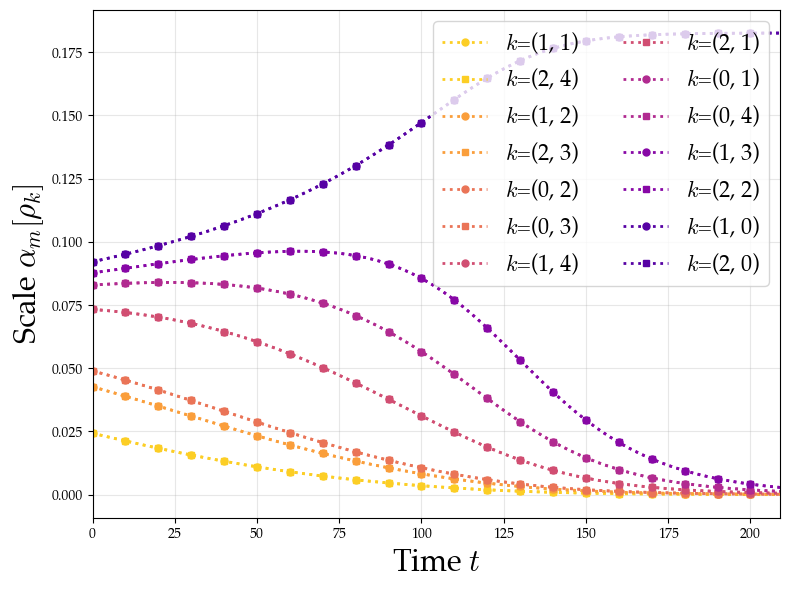

In [474]:
# Scale evolution: conjugate pairs share the same color (plasma, deeper=larger init scale)
# Within each pair: solid line for k, dashed for −k

basis_pa   = trainer_pa.basis
d_vocab_pa = config_pa.d_vocab
snapshot_every_pa = config_pa.snapshot_every
markevery  = max(1, 1000 // snapshot_every_pa)

# ── Build conjugate pairs from non-trivial frequencies ────────────────────
pairs, seen = [], set()
for k in range(1, d_vocab_pa):
    if k in seen:
        continue
    k_t      = basis_pa.get_frequency_tuple(k)
    neg_k_t  = tuple((-kj) % nj for kj, nj in zip(k_t, basis_pa.n))
    neg_k    = basis_pa.tuple_to_index(neg_k_t)
    pair     = (k, neg_k) if neg_k != k else (k,)
    pairs.append(pair)
    seen.update(pair)

# ── Sort pairs by initial scale (|θ̂[k]| = |θ̂[−k]| for real θ) ──────────
# smaller initial scale → lower plasma value (deeper/cooler)
# larger initial scale  → higher plasma value (brighter)
pair_init_scale = [alpha_traj[0, pair[0]] for pair in pairs]
sorted_order    = np.argsort(pair_init_scale)              # ascending
pairs_sorted    = [pairs[i] for i in sorted_order]

cmap_pa  = plt.cm.plasma
n_pairs  = len(pairs_sorted)

fig, ax = plt.subplots(figsize=(8, 6))

# Convert epochs to time: t = lr * epoch
times_pa = epochs_pa * config_pa.stage1_lr

for p_idx, pair in enumerate(pairs_sorted):
    color = cmap_pa(0.90 - 0.75 * p_idx / (n_pairs - 1))  # [0.90, 0.15] → bright to deeper/purple
    for i, k in enumerate(pair):
        k_label = str(basis_pa.get_frequency_tuple(k))
        ls      = ':' if i == 1 else ':'   # dotted for both; marker differs
        ax.plot(times_pa, alpha_traj[:, k],
                color=color, linewidth=2, linestyle=ls,
                marker='o' if i == 0 else 's', markersize=5, markevery=markevery,
                label=rf'$k$={k_label}')

ax.set_xlabel(r'Time $t$', fontsize=22)
ax.set_ylabel(r'Scale $\alpha_m[\rho_k]$', fontsize=22)


ax.set_xlim(times_pa[0], times_pa[-1])
ax.legend(fontsize=16, ncol=2, loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/abelian_scale_competition.jpg', format='jpg', dpi=300, bbox_inches='tight')
plt.show()
